In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input/caltech256/256_ObjectCategories'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import torch
import time
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
import torch.nn.functional as F
from torch.optim.lr_scheduler import StepLR, ReduceLROnPlateau
import numpy as np

# =====================================
# IMPROVED ALEXNET WITH BETTER ARCHITECTURE
# =====================================

class ImprovedAlexNet(nn.Module):
    def __init__(self, num_classes=257):
        super(ImprovedAlexNet, self).__init__()
        
        # Enhanced feature extraction with batch normalization and dropout
        self.features = nn.Sequential(
            # First conv block
            nn.Conv2d(3, 64, kernel_size=11, stride=4, padding=2),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Dropout2d(0.1),
            
            # Second conv block
            nn.Conv2d(64, 192, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(192),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Dropout2d(0.1),
            
            # Third conv block
            nn.Conv2d(192, 384, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(384),
            nn.ReLU(inplace=True),
            
            # Fourth conv block
            nn.Conv2d(384, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            
            # Fifth conv block
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        
        # Adaptive pooling for consistent output size
        self.avgpool = nn.AdaptiveAvgPool2d((6, 6))
        
        # Enhanced classifier with proper regularization
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256 * 6 * 6, 4096),
            nn.BatchNorm1d(4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 2048),
            nn.BatchNorm1d(2048),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(2048, num_classes),
        )
        
        # Initialize weights properly
        self._initialize_weights()
    
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

# =====================================
# ADVANCED DATA AUGMENTATION
# =====================================

# Training transforms with heavy augmentation
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    ),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1),
        scale=(0.9, 1.1),
        shear=10
    ),
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0))
    ], p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.33), ratio=(0.3, 3.3))
])

# Validation transforms (no augmentation)
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# =====================================
# IMPROVED DATASET LOADING
# =====================================

def create_data_loaders(dataset_path, batch_size=64, val_split=0.2):
    """
    Create improved data loaders with better sampling
    """
    # Load full dataset first
    full_dataset = datasets.ImageFolder(dataset_path)
    
    # Get class counts for balanced sampling
    class_counts = {}
    for _, label in full_dataset.samples:
        class_counts[label] = class_counts.get(label, 0) + 1
    
    print(f"Dataset statistics:")
    print(f"Total samples: {len(full_dataset)}")
    print(f"Number of classes: {len(full_dataset.classes)}")
    print(f"Min samples per class: {min(class_counts.values())}")
    print(f"Max samples per class: {max(class_counts.values())}")
    
    # Split dataset
    train_size = int((1 - val_split) * len(full_dataset))
    val_size = len(full_dataset) - train_size
    
    # Use generator for reproducible splits
    generator = torch.Generator().manual_seed(42)
    train_dataset, val_dataset = torch.utils.data.random_split(
        full_dataset, [train_size, val_size], generator=generator
    )
    
    # Apply transforms
    train_dataset.dataset.transform = train_transform
    val_dataset.dataset.transform = val_transform
    
    # Create data loaders with improved sampling
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=4,
        pin_memory=True,
        drop_last=True
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )
    
    return train_loader, val_loader, full_dataset.classes

# =====================================
# ADVANCED TRAINING LOOP
# =====================================

def train_model_advanced(model, train_loader, val_loader, num_classes, device, epochs=50):
    """
    Advanced training with multiple optimizations - keeps best model in memory
    """
    # Use CrossEntropyLoss 
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    
    # Advanced optimizer with weight decay
    optimizer = optim.AdamW(
        model.parameters(),
        lr=0.001,
        weight_decay=0.01,
        betas=(0.9, 0.999)
    )
    
    # Learning rate scheduler
    scheduler = ReduceLROnPlateau(
        optimizer, 
        mode='max', 
        factor=0.5, 
        patience=5, 
        verbose=True,
        min_lr=1e-6
    )
    
    # Training tracking
    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []
    
    best_val_acc = 0.0
    best_model_state = None  # Store best model state in memory
    patience_counter = 0
    max_patience = 15
    
    print(f"Starting training for {epochs} epochs...")
    print(f"Device: {device}")
    print(f"Number of classes: {num_classes}")
    print("-" * 60)
    
    for epoch in range(epochs):
        start_time = time.time()
        
        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)
            
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            
            # Gradient clipping for stability
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            
            train_loss += loss.item()
            pred = output.argmax(dim=1, keepdim=True)
            train_correct += pred.eq(target.view_as(pred)).sum().item()
            train_total += target.size(0)
            
            # Print progress every 100 batches
            if batch_idx % 100 == 0:
                print(f'Epoch {epoch+1}, Batch {batch_idx}/{len(train_loader)}, '
                      f'Loss: {loss.item():.4f}, '
                      f'Acc: {100.*train_correct/train_total:.2f}%')
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for data, target in val_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                loss = criterion(output, target)
                
                val_loss += loss.item()
                pred = output.argmax(dim=1, keepdim=True)
                val_correct += pred.eq(target.view_as(pred)).sum().item()
                val_total += target.size(0)
        
        # Calculate metrics
        avg_train_loss = train_loss / len(train_loader)
        train_acc = 100. * train_correct / train_total
        avg_val_loss = val_loss / len(val_loader)
        val_acc = 100. * val_correct / val_total
        
        # Store metrics
        train_losses.append(avg_train_loss)
        train_accuracies.append(train_acc)
        val_losses.append(avg_val_loss)
        val_accuracies.append(val_acc)
        
        # Update learning rate
        scheduler.step(val_acc)
        
        # Keep track of best model state in memory
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()  # Store best model state
            patience_counter = 0
            print(f"✓ New best model saved in memory! Validation accuracy: {val_acc:.2f}%")
        else:
            patience_counter += 1
        
        epoch_time = time.time() - start_time
        current_lr = optimizer.param_groups[0]['lr']
        
        print(f'Epoch {epoch+1}/{epochs}:')
        print(f'  Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.2f}%')
        print(f'  Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.2f}%')
        print(f'  Time: {epoch_time:.1f}s, LR: {current_lr:.2e}')
        print(f'  Best Val Acc: {best_val_acc:.2f}%')
        print("-" * 60)
        
        # Early stopping
        if patience_counter >= max_patience:
            print(f"Early stopping triggered after {epoch+1} epochs")
            break
    
    # Load best model state back into the model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"✓ Loaded best model state with validation accuracy: {best_val_acc:.2f}%")
    
    return {
        'train_losses': train_losses,
        'train_accuracies': train_accuracies,
        'val_losses': val_losses,
        'val_accuracies': val_accuracies,
        'best_val_acc': best_val_acc
    }

# =====================================
# MODEL EVALUATION
# =====================================

def evaluate_model(model, test_loader, device, class_names):
    """
    Comprehensive model evaluation
    """
    model.eval()
    correct = 0
    total = 0
    class_correct = {}
    class_total = {}
    
    # Initialize per-class counters
    for class_name in class_names:
        class_correct[class_name] = 0
        class_total[class_name] = 0
    
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            outputs = model(data)
            _, predicted = torch.max(outputs, 1)
            
            total += target.size(0)
            correct += (predicted == target).sum().item()
            
            # Per-class accuracy
            for i in range(target.size(0)):
                label = target[i].item()
                class_name = class_names[label]
                class_total[class_name] += 1
                if predicted[i] == target[i]:
                    class_correct[class_name] += 1
    
    overall_acc = 100 * correct / total
    
    print(f"\nOverall Test Accuracy: {overall_acc:.2f}%")
    print(f"Total samples: {total}")
    
    # Show per-class accuracies for top/bottom performing classes
    class_accs = {}
    for class_name in class_names:
        if class_total[class_name] > 0:
            class_accs[class_name] = 100 * class_correct[class_name] / class_total[class_name]
    
    # Sort by accuracy
    sorted_classes = sorted(class_accs.items(), key=lambda x: x[1], reverse=True)
    
    print("\nTop 10 performing classes:")
    for i, (class_name, acc) in enumerate(sorted_classes[:10]):
        print(f"  {i+1}. {class_name}: {acc:.1f}%")
    
    print("\nBottom 10 performing classes:")
    for i, (class_name, acc) in enumerate(sorted_classes[-10:]):
        print(f"  {i+1}. {class_name}: {acc:.1f}%")
    
    return overall_acc

# =====================================
# MAIN EXECUTION
# =====================================

def main():
    # Setup
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    
    # Dataset path
    dataset_path = '/kaggle/input/caltech256/256_ObjectCategories'
    
    # Create improved data loaders
    train_loader, val_loader, class_names = create_data_loaders(
        dataset_path, 
        batch_size=32,  # Smaller batch size for better gradient estimates
        val_split=0.2
    )
    
    # Create improved model
    model = ImprovedAlexNet(num_classes=len(class_names))
    model.to(device)
    
    # Count parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    print(f"\nModel Statistics:")
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    
    # Train model
    print("\n" + "="*60)
    print("STARTING IMPROVED TRAINING")
    print("="*60)
    
    history = train_model_advanced(
        model, 
        train_loader, 
        val_loader, 
        len(class_names), 
        device, 
        epochs=25 # Reduced epochs with early stopping
    )
    
    
    print("\n" + "="*60)
    print("FINAL MODEL EVALUATION")
    print("="*60)
    
    final_acc = evaluate_model(model, val_loader, device, class_names)
    
    print(f"\n TRAINING COMPLETE!")
    print(f"Best Validation Accuracy: {history['best_val_acc']:.2f}%")
    print(f"Final Test Accuracy: {final_acc:.2f}%")
    
    return model, history, class_names

# Run the improved training
if __name__ == "__main__":
    model, history, class_names = main()


Using device: cuda
Dataset statistics:
Total samples: 30607
Number of classes: 257
Min samples per class: 80
Max samples per class: 827

Model Statistics:
Total parameters: 49,154,369
Trainable parameters: 49,154,369

STARTING IMPROVED TRAINING
Starting training for 25 epochs...
Device: cuda
Number of classes: 257
------------------------------------------------------------


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1, Batch 0/765, Loss: 5.6539, Acc: 0.00%
Epoch 1, Batch 100/765, Loss: 5.6491, Acc: 4.61%
Epoch 1, Batch 200/765, Loss: 5.1460, Acc: 5.60%
Epoch 1, Batch 300/765, Loss: 5.1551, Acc: 6.43%
Epoch 1, Batch 400/765, Loss: 5.4530, Acc: 7.19%
Epoch 1, Batch 500/765, Loss: 5.2925, Acc: 7.60%
Epoch 1, Batch 600/765, Loss: 5.2721, Acc: 8.17%
Epoch 1, Batch 700/765, Loss: 4.9162, Acc: 8.51%
✓ New best model saved in memory! Validation accuracy: 12.68%
Epoch 1/25:
  Train Loss: 5.2764, Train Acc: 8.80%
  Val Loss: 4.8096, Val Acc: 12.68%
  Time: 84.7s, LR: 1.00e-03
  Best Val Acc: 12.68%
------------------------------------------------------------
Epoch 2, Batch 0/765, Loss: 4.7038, Acc: 18.75%
Epoch 2, Batch 100/765, Loss: 4.6685, Acc: 13.55%
Epoch 2, Batch 200/765, Loss: 4.6112, Acc: 13.29%
Epoch 2, Batch 300/765, Loss: 4.5146, Acc: 13.48%
Epoch 2, Batch 400/765, Loss: 4.3709, Acc: 13.87%
Epoch 2, Batch 500/765, Loss: 4.7087, Acc: 14.38%
Epoch 2, Batch 600/765, Loss: 4.7194, Acc: 14.94%
E


STARTING GRAD-CAM ANALYSIS
=== GRAD-CAM ANALYSIS ===
Analyzing 3 images from test set...

--- Image 1 ---


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1830: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


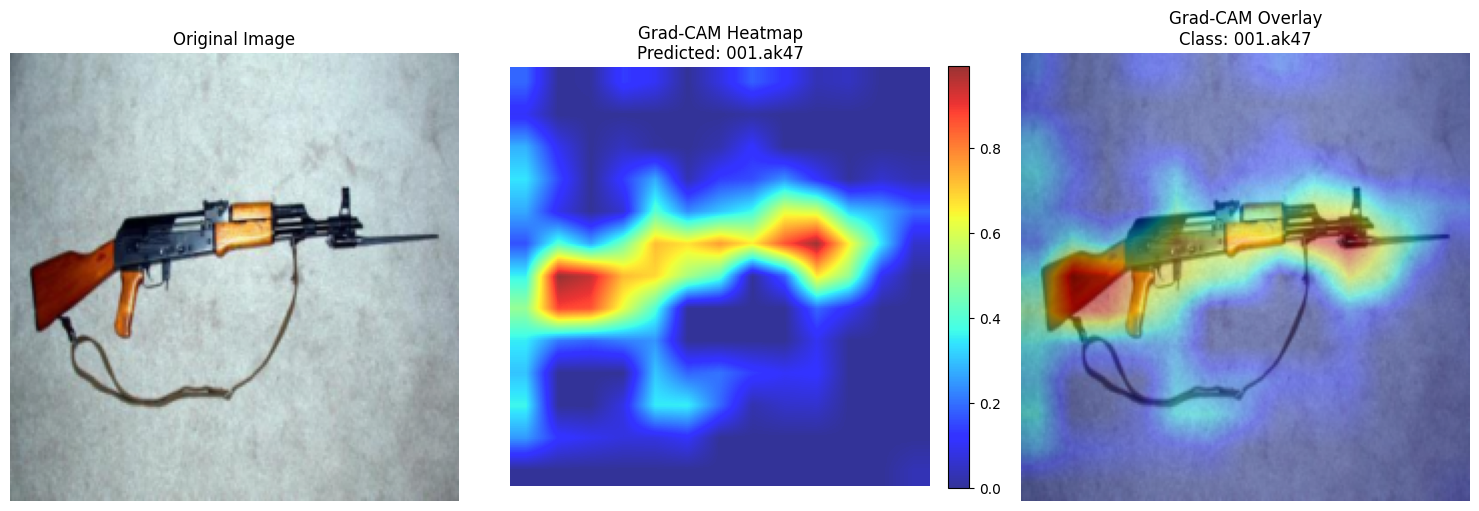

Predicted Class: 001.ak47
Confidence: 0.9928
Top 3 predictions:
  1. 001.ak47: 0.9928
  2. 172.revolver-101: 0.0007
  3. 116.iguana: 0.0006
True Label: 001.ak47
--------------------------------------------------
--- Image 2 ---


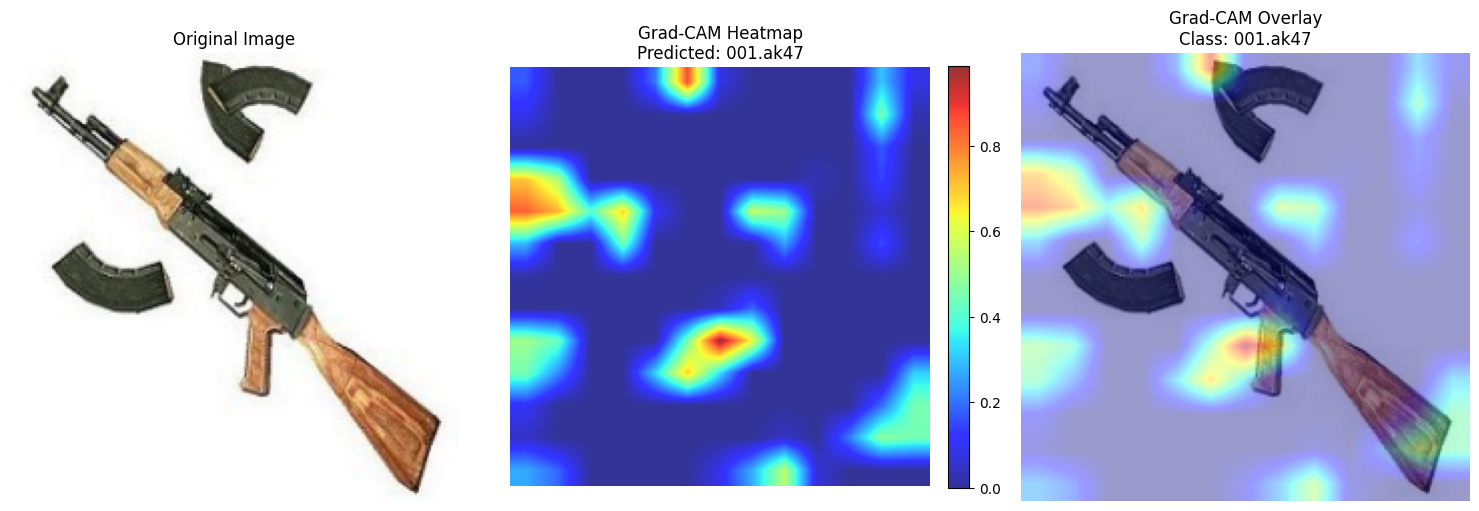

Predicted Class: 001.ak47
Confidence: 0.9995
Top 3 predictions:
  1. 001.ak47: 0.9995
  2. 173.rifle: 0.0001
  3. 231.tripod: 0.0000
True Label: 001.ak47
--------------------------------------------------
--- Image 3 ---


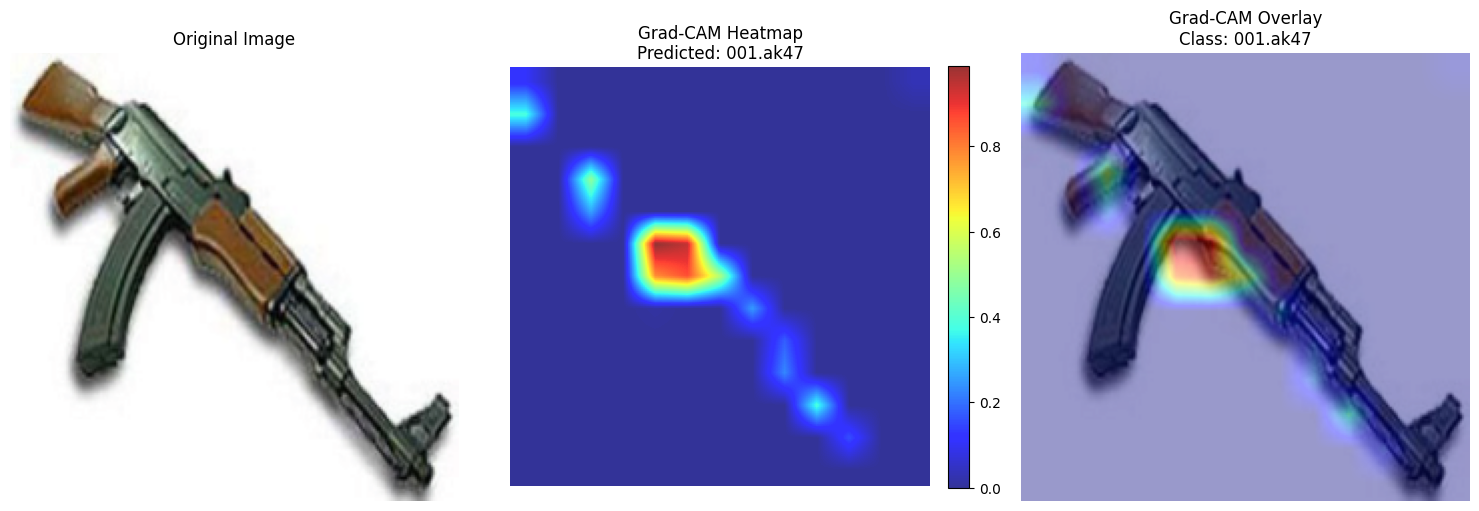

Predicted Class: 001.ak47
Confidence: 0.9903
Top 3 predictions:
  1. 001.ak47: 0.9903
  2. 231.tripod: 0.0019
  3. 173.rifle: 0.0015
True Label: 001.ak47
--------------------------------------------------

CAM ANALYSIS COMPLETE


In [14]:
# ================================
# CLASS ACTIVATION MAPPING (CAM) IMPLEMENTATION
# ================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch.nn.functional as F

class GradCAM:

    
    def __init__(self, model, target_layer, device):
        self.model = model
        self.target_layer = target_layer
        self.device = device  # Store device for proper tensor handling
        self.gradients = None
        self.activations = None
        
        # Register hooks
        self.forward_hook = target_layer.register_forward_hook(self.save_activation)
        self.backward_hook = target_layer.register_backward_hook(self.save_gradient)
    
    def save_activation(self, module, input, output):
        """Hook to save forward pass activations"""
        self.activations = output
    
    def save_gradient(self, module, grad_input, grad_output):
        """Hook to save backward pass gradients"""
        self.gradients = grad_output[0]
    
    def generate_cam(self, input_tensor, class_idx=None):
        """
        Generate Grad-CAM heatmap for given input and class
        
        Args:
            input_tensor: Input image tensor (1, C, H, W) - will be moved to device
            class_idx: Target class index (if None, uses predicted class)
        
        Returns:
            cam: Grad-CAM heatmap
            predicted_class: Predicted class index
        """
        # Ensure input tensor is on the correct device
        input_tensor = input_tensor.to(self.device)
        
        # Forward pass
        self.model.eval()
        output = self.model(input_tensor)
        
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
        
        # Zero gradients
        self.model.zero_grad()
        
        # Backward pass for target class
        class_score = output[0, class_idx]
        class_score.backward()
        
        # Get gradients and activations
        gradients = self.gradients[0]  # (C, H, W)
        activations = self.activations[0]  # (C, H, W)
        
        # Calculate importance weights (global average pooling of gradients)
        weights = torch.mean(gradients, dim=[1, 2])  # (C,)
        
        # Generate weighted combination of activation maps
        cam = torch.zeros(activations.shape[1:], dtype=torch.float32, device=self.device)  # (H, W)
        for i, w in enumerate(weights):
            cam += w * activations[i, :, :]
        
        # Apply ReLU and normalize
        cam = F.relu(cam)
        cam = cam / torch.max(cam) if torch.max(cam) > 0 else cam
        
        return cam.detach().cpu().numpy(), class_idx
    
    def cleanup(self):
        """Remove hooks"""
        self.forward_hook.remove()
        self.backward_hook.remove()

def visualize_gradcam(model, image_tensor, original_image, class_names, device, save_path=None):
    """
    Create and visualize Grad-CAM heatmaps
    
    Args:
        model: Trained model
        image_tensor: Preprocessed image tensor
        original_image: Original PIL image
        class_names: List of class names
        device: Device (CPU/CUDA) where model is located
        save_path: Path to save visualization
    """
    # Initialize Grad-CAM with the last convolutional layer
    # For AlexNet, we use the last conv layer before avgpool
    target_layer = model.features[-4]  # Last Conv2d layer (before final ReLU and MaxPool)
    grad_cam = GradCAM(model, target_layer, device)
    
    try:
        # Generate CAM - pass single tensor with batch dimension
        cam, predicted_class = grad_cam.generate_cam(image_tensor.unsqueeze(0))
        
        # Resize CAM to match input image size
        original_size = original_image.size
        cam_resized = cv2.resize(cam, original_size)
        
        # Create visualization
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        # Original image
        axes[0].imshow(original_image)
        axes[0].set_title('Original Image')
        axes[0].axis('off')
        
        # Grad-CAM heatmap
        im1 = axes[1].imshow(cam_resized, cmap='jet', alpha=0.8)
        axes[1].set_title(f'Grad-CAM Heatmap\nPredicted: {class_names[predicted_class]}')
        axes[1].axis('off')
        plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
        
        # Overlay
        axes[2].imshow(original_image)
        axes[2].imshow(cam_resized, cmap='jet', alpha=0.4)
        axes[2].set_title(f'Grad-CAM Overlay\nClass: {class_names[predicted_class]}')
        axes[2].axis('off')
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
        
        # Print prediction confidence
        with torch.no_grad():
            model.eval()
            # Ensure tensor is on correct device for confidence calculation
            input_for_confidence = image_tensor.unsqueeze(0).to(device)
            output = model(input_for_confidence)
            probabilities = F.softmax(output, dim=1)
            confidence = probabilities[0, predicted_class].item()
            print(f"Predicted Class: {class_names[predicted_class]}")
            print(f"Confidence: {confidence:.4f}")
            print(f"Top 3 predictions:")
            top3_prob, top3_idx = torch.topk(probabilities, 3)
            for i in range(3):
                print(f"  {i+1}. {class_names[top3_idx[0][i]]}: {top3_prob[0][i]:.4f}")
        
    finally:
        grad_cam.cleanup()

def analyze_multiple_images(model, test_loader, dataset, device, num_images=5):
    """
    Analyze multiple images with Grad-CAM
    
    Args:
        model: Trained model
        test_loader: Test data loader
        dataset: Dataset object (for class names)
        device: Device where model is located
        num_images: Number of images to analyze
    """
    model.eval()
    class_names = dataset.classes
    
    # Get some test images
    data_iter = iter(test_loader)
    images, labels = next(data_iter)
    
    # Inverse transform for visualization
    inv_normalize = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )
    
    print("=== GRAD-CAM ANALYSIS ===")
    print(f"Analyzing {min(num_images, len(images))} images from test set...\n")
    
    for i in range(min(num_images, len(images))):
        print(f"--- Image {i+1} ---")
        
        # Get original image for visualization
        img_denorm = inv_normalize(images[i])
        img_denorm = torch.clamp(img_denorm, 0, 1)
        original_image = transforms.ToPILImage()(img_denorm)
        
        # Generate and visualize Grad-CAM
        visualize_gradcam(
            model, 
            images[i],  # This tensor will be moved to device inside visualize_gradcam
            original_image, 
            class_names,
            device,  # Pass device parameter
            save_path=f'gradcam_analysis_image_{i+1}.png'
        )
        
        print(f"True Label: {class_names[labels[i]]}")
        print("-" * 50)

# Additional analysis function for single image
def analyze_single_image(model, image_path, transform, class_names, device):
    """
    Analyze a single image file with Grad-CAM
    
    Args:
        model: Trained model
        image_path: Path to image file
        transform: Image preprocessing transform
        class_names: List of class names
        device: Device where model is located
    """
    # Load and preprocess image
    original_image = Image.open(image_path).convert('RGB')
    image_tensor = transform(original_image)
    
    # Generate Grad-CAM visualization
    visualize_gradcam(model, image_tensor, original_image, class_names, device)

def create_data_loader_for_gradcam(dataset_path, batch_size=32):
    """
    Create a validation data loader with only minimal preprocessing 
    suitable for Grad-CAM visualizations (no augmentation).
    """
    val_transform = transforms.Compose([
        transforms.Resize((224, 224)),  # Keep size consistent with model input
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    dataset = datasets.ImageFolder(root=dataset_path, transform=val_transform)

    val_loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )

    return val_loader, dataset

# Redefine dataset_path and device
# Recreate val_loader and full_dataset
dataset_path = '/kaggle/input/caltech256/256_ObjectCategories'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Recreate with full_dataset returned
val_loader, full_dataset = create_data_loader_for_gradcam(
    dataset_path, 
    batch_size=32
)

# Run Grad-CAM on a few images
print("\n" + "="*60)
print("STARTING GRAD-CAM ANALYSIS")
print("="*60)

analyze_multiple_images(
    model=model,
    test_loader=val_loader,
    dataset=full_dataset,
    device=device,
    num_images=3
)

print("\n" + "="*60)
print("CAM ANALYSIS COMPLETE")
print("="*60)
